In [ ]:
!pip3 install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [21]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import timeit
from googletrans import Translator
import numpy as np
import statsforecast 
sns.set_style('whitegrid')
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.tsa.seasonal import seasonal_decompose
from statsforecast import StatsForecast
from statsforecast.models import (AutoARIMA, AutoETS, HoltWinters, SeasonalNaive, HistoricAverage)
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

In [6]:
client=bigquery.Client('myprojectbq-328820')

query = "SELECT primaryName, avg_runtime, startYear, genres FROM `myprojectbq-328820.imdb.fct_titles` where startYear > 2000 and titleType='movie'"
df = client.query(query).to_dataframe()

# Data Preparation and Cleaning

In [ ]:
## Checking for null values
df.isnull().sum()


primaryName        0
avg_runtime    63701
startYear          0
genres         16086
dtype: int64

There is a high number of missing values for the average runtime and we look at the proportion to the total rows in our database, which is around 1.5%. Therefore, we delete the missing values as we don't expect to skew the results.

In [ ]:
print('The percentage of null values in avg_runtime is: ' + str(round(df['avg_runtime'].isnull().sum()/df.shape[0] * 100, 2)) + '%')

The percentage of null values in avg_runtime is: 1.53%


In [15]:
# We drop the rows with null values in the dataframe to ensure that our analysis is based on complete data. 
df.dropna(inplace=True)

# Main Analysis
In the genres column there are various categories that could include music videos, clips, etc. In this case we keep: i) Adventure, ii) Comedy, iii) Drama, and iv) Horror.

In [16]:
df_all = df[df['genres'].str.contains('Adventure|Comedy|Drama|Horror')]

In [18]:
# Removing the extreme values on the 1% and 99% of the average runtime per movie in the dataset.

df_all = df_all[(df_all['avg_runtime']>df_all['avg_runtime'].quantile(0.01)) & (df_all['avg_runtime']<df_all['avg_runtime'].quantile(0.99))]

In [19]:
df_all.set_index('startYear', inplace=True)
df_all=df_all.groupby('startYear')['avg_runtime'].mean().to_frame()

### Insights on decomposition

- There is an upward trend for the average duration as seen in the [Trend] plot from year-to-year. 
- The [Observed] and [Seasonal] plots, don't provide any additional insights as the data are at the annual level and no seasonality would be expected on a particular year, except if we had data at a monthly level!
- The residuals plot doesn't give any information on extreme values, so in the decomposition equation there isn't any useful information.


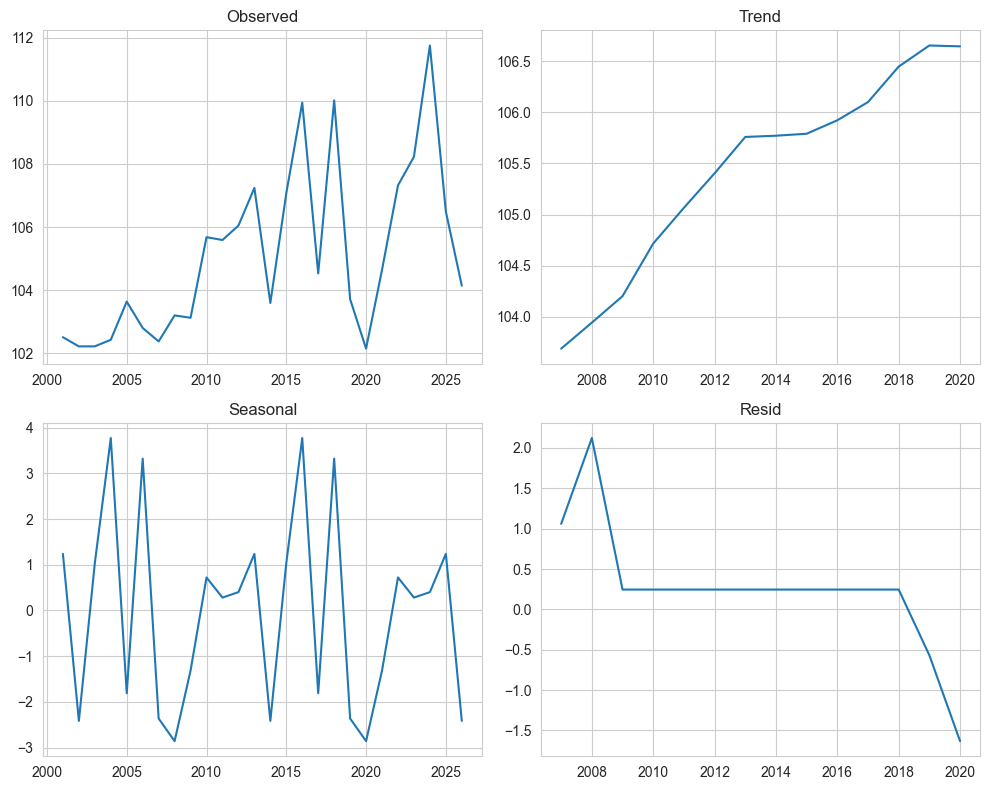

In [ ]:
decompose = seasonal_decompose(
    df_all['avg_runtime'],
    model='additive',
    period=12
)


# 2. Plot all components
methods = ['observed', 'trend', 'seasonal', 'resid']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, m in enumerate(methods):
    ax = axes[i//2, i%2]
    ax.plot(getattr(decompose, m))
    ax.set_title(m.capitalize())

plt.tight_layout()
plt.show()


## ETS Models 

In [35]:
df_all.reset_index(inplace=True)

In [36]:
df_all['startYear'] = pd.to_datetime(df_all['startYear'], format='%Y')

In [41]:
df_all_cp2.columns 

Index(['ds', 'y'], dtype='object')

In [40]:
df_all_cp2 = df_all.rename(columns={'startYear': 'ds', 'avg_runtime': 'y'})
#df_all['unique_id'] = 'all'

In [42]:
df_all_cp2['unique_id'] = 'movies'

In [43]:
df_all_cp2.columns

Index(['ds', 'y', 'unique_id'], dtype='object')

Based on the data we have since year 2020, we can use the forecast attribute by the AutoETS model for the next 10 years. A first view on the chart shows a forecast greater than the average of the previous years than 2025. Moreover, looking at the forecast_table of AutoETS, the average forecasted runtime is around 115mins that is much lower than 2025 average runtime.



In [ ]:
models = [AutoETS(season_length=20)]
movies_ETS = StatsForecast(models=models, freq='Y')

fit = movies_ETS.fit(df_all_cp2)
forecast = fit.predict(h=10, level=[10])


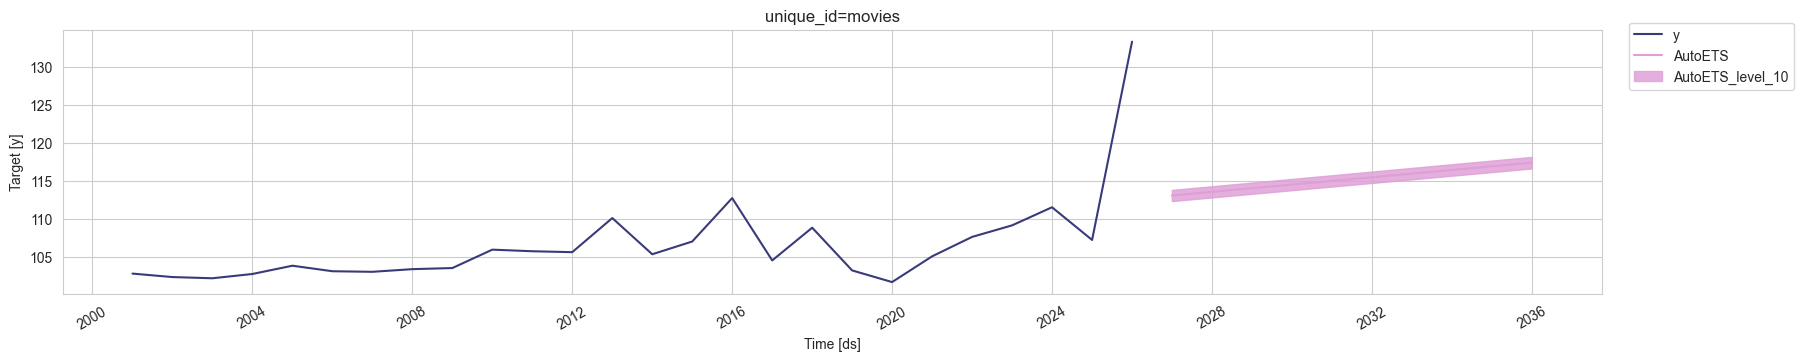

In [15]:
movies_ETS.plot(df_all_cp2, forecast, level=[10])

In [101]:
movies_ETS.predict(10)

,unique_id,ds,AutoETS
0,movies,2026-12-31,113.077592
1,movies,2027-12-31,113.558274
2,movies,2028-12-31,114.038955
3,movies,2029-12-31,114.519637
4,movies,2030-12-31,115.000319
5,movies,2031-12-31,115.481000
6,movies,2032-12-31,115.961682
7,movies,2033-12-31,116.442364
8,movies,2034-12-31,116.923045
9,movies,2035-12-31,117.403727


Due to the big change in the movies duration in 2025, the ETS model isn't a good representation of the time series. 
One of the next steps to investigate is differencing to turn the data into stationary.

## ARIMA


In [56]:
## Checking for stationarity with Augmented Dickey-Fuller test

from statsmodels.tsa.stattools import adfuller

def adfuller_test(series):
    result = adfuller(series, autolag='AIC')
    p_value=result[1]
    if result[1] <= 0.05:
        return print("The series is stationary")
    else:
        return print(f"The series is not stationary (p_value: {p_value:.4f})")
    
    
result = adfuller_test(df_all_cp2['y'])


The series is not stationary (p_value: 0.6482)


The ADF test has shown a p-value>.05, and the next step is to apply non-stationary methods.
The nest steps are to we apply differencing methods to normalize the year-to-year differences.
The methods being used are:
- MA(4)
- MA(12)
- diff(1)

The outcome of differencing, didn't improve our forecasting methods. The charts show a spike on the average run time in 2026, compared to the other years.

In [60]:
df_all_cp2['diff'] = df_all_cp2['y'].diff()
df_all_cp2['MA4'] = df_all_cp2['y'].rolling(window=4).mean()
df_all_cp2['MA12'] = df_all_cp2['y'].rolling(window=12).mean()
df_all_cp2['log'] = np.log(df_all_cp2['y'])

In [25]:
df_all_cp2

,ds,y,unique_id,diff,MA4,MA12,log
0,2001-01-01,102.782108,movies,NaN,NaN,NaN,4.632611
1,2002-01-01,102.326928,movies,-0.455180,NaN,NaN,4.628173
2,2003-01-01,102.167818,movies,-0.159110,NaN,NaN,4.626617
3,2004-01-01,102.731535,movies,0.563718,102.502097,NaN,4.632119
4,2005-01-01,103.823186,movies,1.091651,102.762367,NaN,4.642689
5,2006-01-01,103.095714,movies,-0.727472,102.954563,NaN,4.635658
6,2007-01-01,103.018142,movies,-0.077572,103.167144,NaN,4.634905
7,2008-01-01,103.369209,movies,0.351067,103.326563,NaN,4.638307
8,2009-01-01,103.514718,movies,0.145509,103.249446,NaN,4.639714
9,2010-01-01,105.939753,movies,2.425035,103.960455,NaN,4.662871


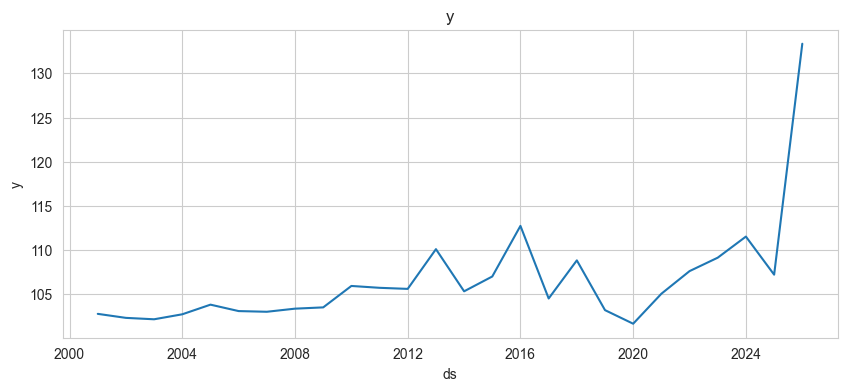

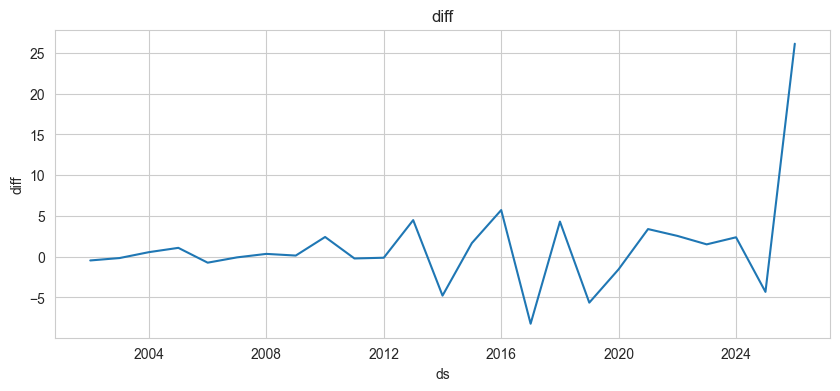

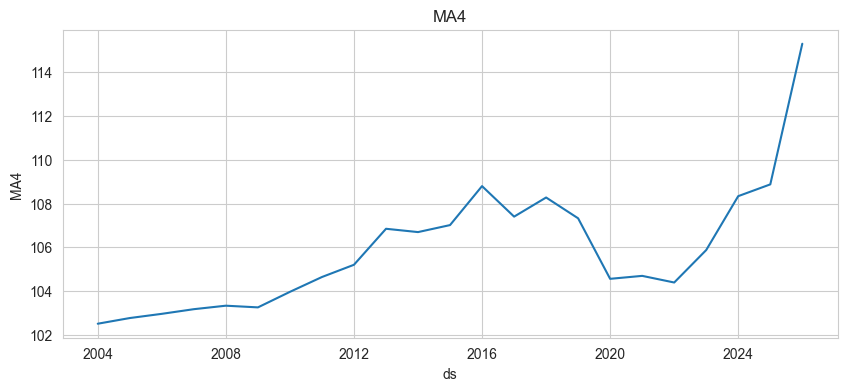

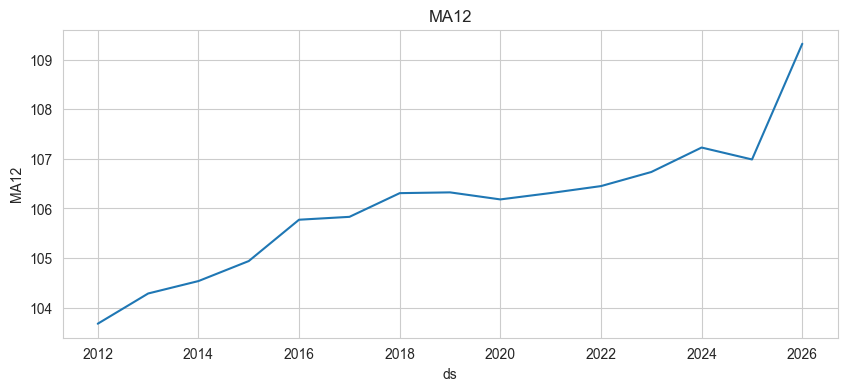

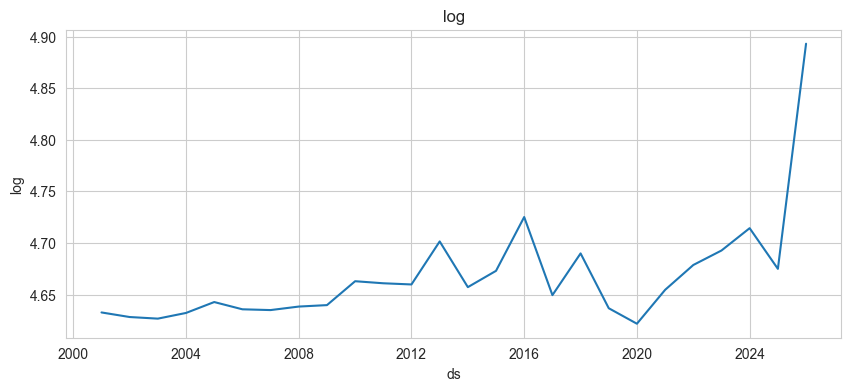

<Axes: >

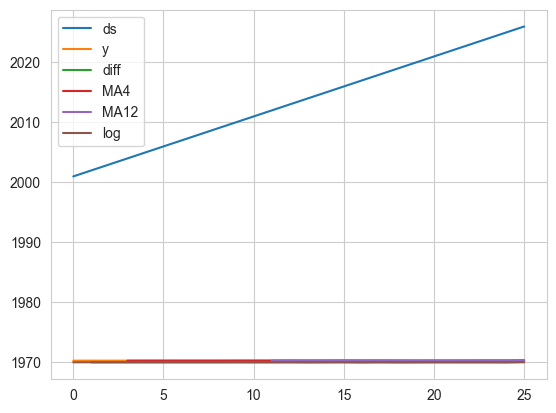

In [29]:
cols = ['ds', 'y', 'diff', 'MA4', 'MA12', 'log']
df_all_cp2 = df_all_cp2[cols]

for i in df_all_cp2.columns:
    if i != 'ds':  # don't plot ds against itself
        plt.figure(figsize=(10,4))
        sns.lineplot(data=df_all_cp2, x='ds', y=i)
        plt.title(i)
        plt.show()

df_all_cp2.plot()


In [65]:
df_all_arima = df_all.rename(columns={'startYear': 'ds', 'avg_runtime': 'y'})
df_all_arima['unique_id']='movies'

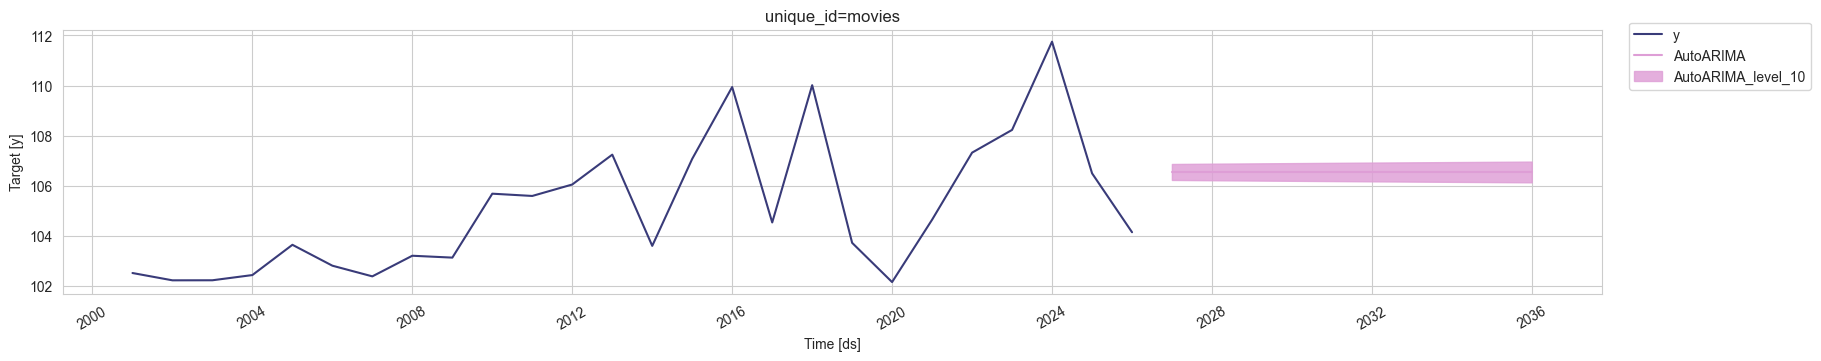

In [ ]:
# A last test to see how our ARIMA model would like for 10 years forecasting. We use the original dataset due to missing values from applying the moving average in the previous steps.
#df_all_cp2=df_all
models = [AutoARIMA(season_length=20)]
sf_arima = StatsForecast(models=models, freq='Y')
fit_arima = sf_arima.fit(df_all_arima)
forecast_arima = fit_arima.predict(h=10, level=[10])
sf_arima.plot(df_all_arima, forecast_arima, level=[10])

## Auto-correlation

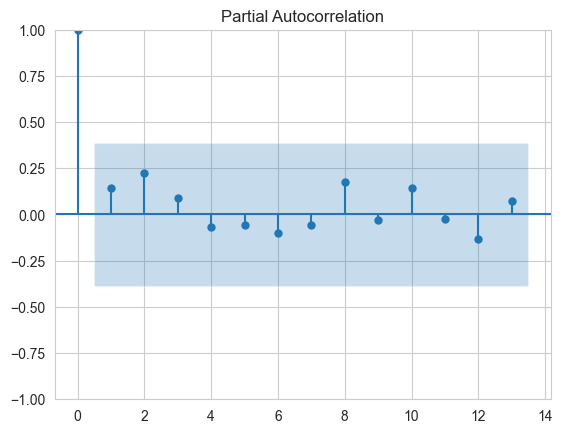

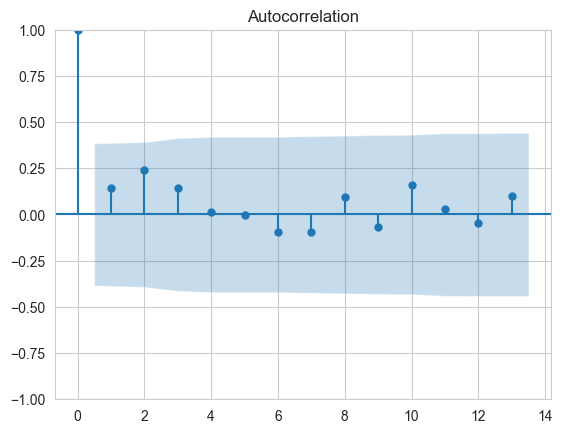

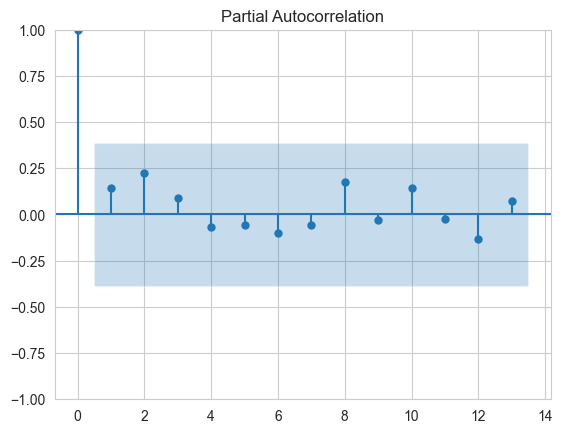

In [33]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_all_cp2['y'], lags=13)
plot_pacf(df_all_cp2['y'], lags=13)